# VIGIL — Interpretable Temporal Deep Learning for ECG Arrhythmia Classification

This notebook implements a reproducible **beat-level, five-class ECG arrhythmia classifier** using the user-specified Kaggle mirror of the MIT-BIH Arrhythmia Database. The five research labels follow an AAMI-style grouping:

| Class | Beat symbols used |
|---|---|
| N — Normal | `N`, `L`, `R`, `e`, `j` |
| S — Supraventricular ectopic | `A`, `a`, `J`, `S` |
| V — Ventricular ectopic | `V`, `E` |
| F — Fusion | `F` |
| Q — Unknown / paced / other | `Q`, `/`, `f` |

The pipeline reads WFDB records and expert annotations, segments causal beat windows, normalizes each beat, builds contiguous beat sequences, and compares Logistic Regression, Random Forest, vanilla RNN, LSTM, GRU, bidirectional LSTM, and bidirectional LSTM with temporal attention. It exports measured metrics, calibration plots, attention and Integrated Gradients artifacts, checkpoints, preprocessing metadata, and an inference bundle for a later FastAPI or UI layer.

> **Scope.** This is a retrospective research prototype, not a clinical diagnostic system. It must not be used for treatment decisions, and the reported results do not establish clinical validity or deployment readiness.

The dataset is a public Kaggle mirror of the MIT-BIH Arrhythmia Database [1]. The original database contains two-channel ECG recordings and beat annotations that are read here through WFDB [2].

In [1]:
# =========================== CONFIGURATION ===========================
from pathlib import Path
import os, json, time, random, warnings, re
from dataclasses import dataclass, asdict

@dataclass
class Config:
    seed: int = 42
    kaggle_dataset: str = 'abdallahwagih/mit-bih-arrhythmia-database'
    data_dir: str = os.getenv('MITBIH_DATA_DIR', '')
    output_dir: str = './artifacts_arrhythmia'
    mode: str = os.getenv('MITBIH_MODE', 'DEBUG')  # DEBUG or FINAL
    beat_pre_samples: int = 90
    beat_post_samples: int = 90
    sequence_length: int = 8
    max_beats_per_class: int = 1200
    batch_size: int = 128
    learning_rate: float = 1e-3
    hidden_size: int = 48
    num_layers: int = 1
    dropout: float = 0.25
    epochs: int = 3
    patience: int = 2
    threshold: float = 0.50
    device: str = 'cuda' if __import__('torch').cuda.is_available() else 'cpu'

CFG = Config()
if CFG.mode.upper() == 'FINAL':
    CFG.max_beats_per_class = 10000
    CFG.epochs = 12
OUTPUT = Path(CFG.output_dir)
for sub in ['models','metrics','plots','explanations','configs','predictions','reports']:
    (OUTPUT/sub).mkdir(parents=True, exist_ok=True)
Path(OUTPUT/'configs'/'config.json').write_text(json.dumps(asdict(CFG), indent=2))
print(json.dumps(asdict(CFG), indent=2))

{
  "seed": 42,
  "kaggle_dataset": "abdallahwagih/mit-bih-arrhythmia-database",
  "data_dir": "",
  "output_dir": "./artifacts_arrhythmia",
  "mode": "DEBUG",
  "beat_pre_samples": 90,
  "beat_post_samples": 90,
  "sequence_length": 8,
  "max_beats_per_class": 1200,
  "batch_size": 128,
  "learning_rate": 0.001,
  "hidden_size": 48,
  "num_layers": 1,
  "dropout": 0.25,
  "epochs": 3,
  "patience": 2,
  "threshold": 0.5,
  "device": "cpu"
}


## 1. Download and inspect the official-format records

The notebook uses the exact KaggleHub identifier supplied for this project. If `MITBIH_DATA_DIR` is set, that path is used. Otherwise the KaggleHub call downloads the dataset into the local cache. No synthetic ECG signals are created and no unrelated dataset is substituted.

In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from collections import Counter, defaultdict
import wfdb
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, roc_auc_score, average_precision_score, log_loss)
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({'figure.figsize':(9,5),'figure.dpi':110,'axes.titleweight':'bold'})

def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic=True; torch.backends.cudnn.benchmark=False
set_seed(CFG.seed)

if not CFG.data_dir:
    try:
        import kagglehub
        CFG.data_dir = kagglehub.dataset_download(CFG.kaggle_dataset)
    except Exception as exc:
        raise RuntimeError('Set MITBIH_DATA_DIR or install/login to KaggleHub before running.') from exc
root = Path(CFG.data_dir)
hea = sorted(root.rglob('*.hea'))
if not hea:
    raise FileNotFoundError(f'No WFDB .hea files found under {root}')
DATA_ROOT = hea[0].parent
RECORDS = sorted(p.stem for p in DATA_ROOT.glob('*.hea'))
print('Data root:', DATA_ROOT)
print('Records:', len(RECORDS), RECORDS[:10])

Data root: /home/ubuntu/.cache/kagglehub/datasets/abdallahwagih/mit-bih-arrhythmia-database/versions/1/mit-bih-arrhythmia-database-1.0.0
Records: 48 ['100', '101', '102', '103', '104', '105', '106', '107', '108', '109']


AAMI class counts: {'N': 90631, 'S': 2781, 'V': 7236, 'Q': 8043, 'F': 803}


,record,subject_id,N,S,V,F,Q
0,100,69,2239,33,1,0,0
1,101,75,1860,3,0,0,2
2,102,84,99,0,4,0,2084
3,103,103,2082,2,0,0,0
4,104,66,163,0,2,0,2064


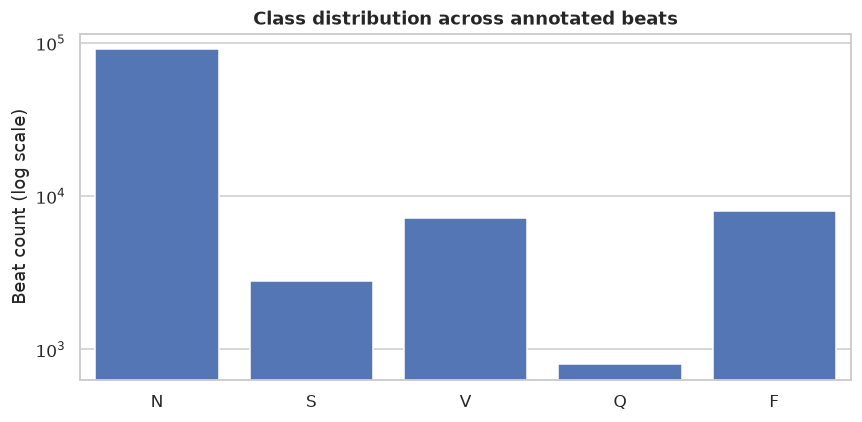

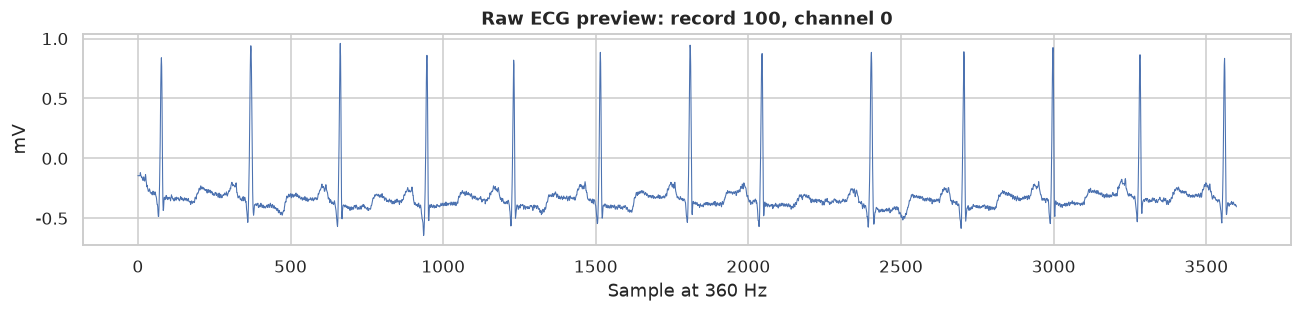

In [3]:
# Dataset audit: record metadata, symbol counts, and one waveform preview.
def subject_id(record):
    try:
        text=(DATA_ROOT/f'{record}.hea').read_text(errors='ignore')
        for line in text.splitlines():
            if line.startswith('#'):
                m=re.search(r'#\s*(\d+)', line)
                if m: return m.group(1)
    except Exception: pass
    return record

AAMI = {
    'N': ['N','L','R','e','j'],
    'S': ['A','a','J','S'],
    'V': ['V','E'],
    'F': ['F'],
    'Q': ['Q','/','f'],
}
SYMBOL_TO_CLASS = {sym:cls for cls,syms in AAMI.items() for sym in syms}
CLASS_NAMES = ['N','S','V','F','Q']; CLASS_TO_INDEX={c:i for i,c in enumerate(CLASS_NAMES)}

def annotation_counts(records):
    counts=Counter(); per_record=[]
    for rec in records:
        ann=wfdb.rdann(str(DATA_ROOT/rec),'atr')
        c=Counter(SYMBOL_TO_CLASS[s] for s in ann.symbol if s in SYMBOL_TO_CLASS)
        counts.update(c); per_record.append({'record':rec,'subject_id':subject_id(rec),**{k:c.get(k,0) for k in CLASS_NAMES}})
    return counts,pd.DataFrame(per_record)

symbol_counts, record_counts = annotation_counts(RECORDS)
print('AAMI class counts:', dict(symbol_counts))
display(record_counts.head())
plt.figure(figsize=(8,4)); sns.barplot(x=list(symbol_counts), y=[symbol_counts[c] for c in CLASS_NAMES], color='#4472C4'); plt.yscale('log'); plt.ylabel('Beat count (log scale)'); plt.title('Class distribution across annotated beats'); plt.tight_layout(); plt.savefig(OUTPUT/'plots'/'class_distribution.png'); plt.show()
rec=RECORDS[0]; sig, fields=wfdb.rdsamp(str(DATA_ROOT/rec)); ann=wfdb.rdann(str(DATA_ROOT/rec),'atr')
plt.figure(figsize=(12,3)); plt.plot(sig[:3600,0],lw=.7); plt.title(f'Raw ECG preview: record {rec}, channel 0'); plt.xlabel('Sample at 360 Hz'); plt.ylabel(fields['units'][0]); plt.tight_layout(); plt.savefig(OUTPUT/'plots'/'raw_ecg_preview.png'); plt.show()

## 2. Leakage-safe beat construction

The split is performed at the **subject/record group level before model fitting**. Beat windows from a held-out subject cannot enter the training set. Within a record, sequences are chronological and contain only the current beat and its preceding beats. The waveform window is centered on the expert annotation sample; the annotation is used only as the target location and not as an input feature. Per-beat robust normalization is fitted directly from that beat's waveform and therefore does not use labels or future beats.

Because the source has repeated recordings and subject-specific morphology, an individual-beat random split would overstate generalization. This notebook therefore uses subject identifiers parsed from WFDB header comments where available, falling back to record ID only when no subject identifier is present.

In [4]:
def load_record_beats(record, pre=90, post=90):
    sig, fields = wfdb.rdsamp(str(DATA_ROOT/record))
    ann=wfdb.rdann(str(DATA_ROOT/record),'atr')
    signal=sig[:,0].astype(np.float32)
    beats=[]
    for sample,sym in zip(ann.sample,ann.symbol):
        if sym not in SYMBOL_TO_CLASS: continue
        start=int(sample)-pre; end=int(sample)+post
        if start<0 or end>len(signal): continue
        beat=signal[start:end].copy()
        med=np.median(beat); scale=np.median(np.abs(beat-med))*1.4826
        if not np.isfinite(scale) or scale<1e-6: scale=np.std(beat)+1e-6
        beat=np.clip((beat-med)/scale,-8,8).astype(np.float32)
        beats.append({'record':record,'subject_id':subject_id(record),'sample':int(sample),'symbol':sym,'class_name':SYMBOL_TO_CLASS[sym],'class_index':CLASS_TO_INDEX[SYMBOL_TO_CLASS[sym]],'beat':beat})
    return beats

def group_split(records, seed=42):
    groups=np.array([subject_id(r) for r in records]); idx=np.arange(len(records))
    gss=GroupShuffleSplit(n_splits=1,test_size=.20,random_state=seed); tr_idx,te_idx=next(gss.split(idx,groups=groups))
    tr_records=[records[i] for i in tr_idx]; te_records=[records[i] for i in te_idx]
    groups_tr=np.array([subject_id(r) for r in tr_records]); idx_tr=np.arange(len(tr_records))
    gss2=GroupShuffleSplit(n_splits=1,test_size=.20,random_state=seed+1); tr2,va2=next(gss2.split(idx_tr,groups=groups_tr))
    return [tr_records[i] for i in tr2],[tr_records[i] for i in va2],te_records

train_records,val_records,test_records=group_split(RECORDS,CFG.seed)
print('Grouped records:',len(train_records),len(val_records),len(test_records))

def collect_beats(records, max_per_class=None):
    all_beats=[]; per_class=Counter()
    for rec in records:
        for b in load_record_beats(rec,CFG.beat_pre_samples,CFG.beat_post_samples):
            if max_per_class is not None and per_class[b['class_name']]>=max_per_class: continue
            all_beats.append(b); per_class[b['class_name']]+=1
    return all_beats

train_beats=collect_beats(train_records,CFG.max_beats_per_class)
val_beats=collect_beats(val_records,CFG.max_beats_per_class)
test_beats=collect_beats(test_records,CFG.max_beats_per_class)
print('Beat counts by split:')
for name,arr in [('train',train_beats),('val',val_beats),('test',test_beats)]: print(name,Counter(b['class_name'] for b in arr), 'total=',len(arr))

Grouped records: 31 7 10


Beat counts by split:
train Counter({'N': 1200, 'S': 1200, 'V': 1200, 'Q': 1200, 'F': 767}) total= 5567
val Counter({'N': 1200, 'V': 1200, 'S': 143, 'F': 23, 'Q': 4}) total= 2570
test Counter({'Q': 1200, 'N': 1200, 'V': 1200, 'S': 542, 'F': 12}) total= 4154


In [5]:
def build_sequences(beats, seq_len=8):
    by_record=defaultdict(list)
    for b in beats: by_record[b['record']].append(b)
    X=[]; y=[]; meta=[]
    for rec,arr in by_record.items():
        arr=sorted(arr,key=lambda b:b['sample'])
        for i,b in enumerate(arr):
            seq=arr[max(0,i-seq_len+1):i+1]
            pad=seq_len-len(seq); waves=np.zeros((seq_len,len(b['beat'])),dtype=np.float32)
            for j,item in enumerate(seq,pad): waves[j]=item['beat']
            X.append(waves); y.append(b['class_index']); meta.append({'record':rec,'subject_id':b['subject_id'],'sample':b['sample'],'symbol':b['symbol'],'class_name':b['class_name']})
    return np.stack(X),np.array(y,dtype=np.int64),pd.DataFrame(meta)

X_train,y_train,meta_train=build_sequences(train_beats,CFG.sequence_length)
X_val,y_val,meta_val=build_sequences(val_beats,CFG.sequence_length)
X_test,y_test,meta_test=build_sequences(test_beats,CFG.sequence_length)
print('Sequence shapes:',X_train.shape,X_val.shape,X_test.shape)
Path(OUTPUT/'configs'/'label_mapping.json').write_text(json.dumps({'class_names':CLASS_NAMES,'symbol_groups':AAMI},indent=2))
Path(OUTPUT/'configs'/'preprocessing.json').write_text(json.dumps({'beat_pre_samples':CFG.beat_pre_samples,'beat_post_samples':CFG.beat_post_samples,'sequence_length':CFG.sequence_length,'normalization':'per-beat robust median/MAD with clipping at +/-8','sample_rate_hz':360},indent=2))

Sequence shapes: (5567, 8, 180) (2570, 8, 180) (4154, 8, 180)


175

## 3. Multiclass metrics and classical baselines

The primary metrics are macro-F1, balanced accuracy, one-vs-rest AUROC, and one-vs-rest AUPRC. Per-class precision, recall, and F1 are reported because overall accuracy can hide failure on rare arrhythmia classes. Calibration is summarized by multiclass Brier score and expected calibration error (ECE).

In [6]:
def ece_multiclass(y,p,n_bins=10):
    conf=p.max(axis=1); pred=p.argmax(axis=1); bins=np.linspace(0,1,n_bins+1); ece=0.0
    for lo,hi in zip(bins[:-1],bins[1:]):
        sel=(conf>=lo)&(conf<=hi if hi==1 else conf<hi)
        if sel.any(): ece += sel.mean()*abs((pred[sel]==y[sel]).mean()-conf[sel].mean())
    return float(ece)

def multiclass_metrics(y,p):
    pred=p.argmax(axis=1); one=label_binarize(y,classes=np.arange(len(CLASS_NAMES)))
    out={'Accuracy':float(accuracy_score(y,pred)),'BalancedAccuracy':float(balanced_accuracy_score(y,pred)),'MacroF1':float(f1_score(y,pred,average='macro',zero_division=0)),'WeightedF1':float(f1_score(y,pred,average='weighted',zero_division=0)),'AUROC_OVR':float(roc_auc_score(one,p,multi_class='ovr',average='macro')),'AUPRC_macro':float(average_precision_score(one,p,average='macro')),'LogLoss':float(log_loss(y,p,labels=np.arange(len(CLASS_NAMES)))),'Brier_multiclass':float(np.mean(np.sum((p-one)**2,axis=1))),'ECE':ece_multiclass(y,p)}
    for i,c in enumerate(CLASS_NAMES):
        out[f'{c}_precision']=float(precision_score(y,pred,labels=[i],average='macro',zero_division=0)); out[f'{c}_recall']=float(recall_score(y,pred,labels=[i],average='macro',zero_division=0)); out[f'{c}_f1']=float(f1_score(y,pred,labels=[i],average='macro',zero_division=0))
    return out

def beat_summary(X):
    # Leakage-safe deterministic representation for the classical baselines.
    last=X[:,-1,:]
    mean=X.mean(axis=1); std=X.std(axis=1); mn=X.min(axis=1); mx=X.max(axis=1); slope=X[:,-1,:]-X[:,0,:]
    return np.concatenate([last,mean,std,mn,mx,slope],axis=1)

def fit_classical():
    A,B,C=beat_summary(X_train),beat_summary(X_val),beat_summary(X_test)
    models={'Logistic Regression':Pipeline([('imputer',SimpleImputer(strategy='median')),('scaler',StandardScaler()),('model',LogisticRegression(max_iter=300,class_weight='balanced',random_state=CFG.seed))]),'Random Forest':Pipeline([('imputer',SimpleImputer(strategy='median')),('model',RandomForestClassifier(n_estimators=120,min_samples_leaf=2,class_weight='balanced_subsample',random_state=CFG.seed,n_jobs=-1))])}
    fitted={}; rows={}
    for name,m in models.items():
        m.fit(A,y_train); p=m.predict_proba(C); fitted[name]=m; rows[name]=multiclass_metrics(y_test,p)
    return pd.DataFrame(rows).T,fitted
baseline_results,baseline_models=fit_classical(); display(baseline_results[['Accuracy','BalancedAccuracy','MacroF1','AUROC_OVR','AUPRC_macro','Brier_multiclass','ECE']])

,Accuracy,BalancedAccuracy,MacroF1,AUROC_OVR,AUPRC_macro,Brier_multiclass,ECE
Logistic Regression,0.563553,0.538812,0.421913,0.730429,0.543088,0.795360,0.374428
Random Forest,0.384449,0.372191,0.218596,0.795148,0.498420,0.820672,0.208755


## 4. Temporal PyTorch models

Each sample is a sequence of the current beat and up to seven preceding beats from the same record. The temporal models operate on beat waveforms and preserve the order of the sequence. The attention model stores a normalized weight for each sequence position. Attention is used as a descriptive diagnostic and is not treated as proof of causal explanation [3].

In [7]:
class ECGDataset(Dataset):
    def __init__(self,X,y): self.X=torch.tensor(X,dtype=torch.float32); self.y=torch.tensor(y,dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self,i): return self.X[i],self.y[i]

class TemporalAttention(nn.Module):
    def __init__(self,dim): super().__init__(); self.score=nn.Sequential(nn.Linear(dim,dim),nn.Tanh(),nn.Linear(dim,1))
    def forward(self,h):
        a=torch.softmax(self.score(h).squeeze(-1),dim=1); return torch.sum(h*a.unsqueeze(-1),dim=1),a

class ECGTemporalClassifier(nn.Module):
    def __init__(self,beat_len,kind,hidden=48,layers=1,dropout=.25,n_classes=5):
        super().__init__(); self.kind=kind; self.encoder=nn.Sequential(nn.Linear(beat_len,96),nn.ReLU(),nn.Dropout(dropout),nn.Linear(96,48),nn.ReLU())
        bidir=kind in ['BiLSTM','BiLSTM_Attention']; base='LSTM' if bidir else kind; cls={'RNN':nn.RNN,'LSTM':nn.LSTM,'GRU':nn.GRU}[base]
        self.rnn=cls(48,hidden,num_layers=layers,batch_first=True,dropout=dropout if layers>1 else 0,bidirectional=bidir); dim=hidden*(2 if bidir else 1)
        self.attn=TemporalAttention(dim) if kind=='BiLSTM_Attention' else None; self.head=nn.Sequential(nn.Dropout(dropout),nn.Linear(dim,n_classes))
    def forward(self,x):
        z=self.encoder(x); h,_=self.rnn(z)
        if self.attn is not None: c,a=self.attn(h); return self.head(c),a
        return self.head(h[:,-1,:]),None

def count_params(m): return int(sum(p.numel() for p in m.parameters() if p.requires_grad))

def infer_torch(model,loader):
    model.eval(); ys=[]; ps=[]; att=[]
    with torch.no_grad():
        for x,y in loader:
            logits,a=model(x.to(CFG.device)); ys.append(y.numpy()); ps.append(torch.softmax(logits,1).cpu().numpy());
            if a is not None: att.append(a.cpu().numpy())
    return np.concatenate(ys),np.concatenate(ps),(np.concatenate(att) if att else None)

def train_model(kind):
    set_seed(CFG.seed); model=ECGTemporalClassifier(X_train.shape[-1],kind,CFG.hidden_size,CFG.num_layers,CFG.dropout).to(CFG.device)
    tr=DataLoader(ECGDataset(X_train,y_train),batch_size=CFG.batch_size,shuffle=True); va=DataLoader(ECGDataset(X_val,y_val),batch_size=CFG.batch_size)
    counts=np.bincount(y_train,minlength=len(CLASS_NAMES)); weights=len(y_train)/(len(CLASS_NAMES)*np.maximum(counts,1)); loss_fn=nn.CrossEntropyLoss(weight=torch.tensor(weights,dtype=torch.float32,device=CFG.device)); opt=torch.optim.Adam(model.parameters(),lr=CFG.learning_rate)
    best=-np.inf; best_state=None; bad=0; hist=[]; started=time.time()
    for ep in range(CFG.epochs):
        model.train(); losses=[]
        for x,y in tr:
            opt.zero_grad(); logits,_=model(x.to(CFG.device)); loss=loss_fn(logits,y.to(CFG.device)); loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(),3); opt.step(); losses.append(loss.item())
        vy,vp,_=infer_torch(model,va); vm=multiclass_metrics(vy,vp); score=vm['MacroF1']; hist.append({'epoch':ep+1,'train_loss':float(np.mean(losses)),'val_macro_f1':score,'val_auroc':vm['AUROC_OVR'],'val_auprc':vm['AUPRC_macro']})
        if score>best: best=score; best_state={k:v.detach().cpu().clone() for k,v in model.state_dict().items()}; bad=0
        else: bad+=1
        if bad>=CFG.patience: break
    if best_state: model.load_state_dict(best_state)
    return model,pd.DataFrame(hist),time.time()-started

In [8]:
deep_models,deep_histories,deep_metrics,attention_cache,train_times,benchmark_meta={}, {}, {}, {}, {}, {}
for kind in ['RNN','LSTM','GRU','BiLSTM','BiLSTM_Attention']:
    model,hist,elapsed=train_model(kind); test_loader=DataLoader(ECGDataset(X_test,y_test),batch_size=CFG.batch_size)
    lat0=time.perf_counter(); yt,pt,att=infer_torch(model,test_loader); latency_ms=(time.perf_counter()-lat0)*1000/max(len(y_test),1)
    deep_models[kind]=model; deep_histories[kind]=hist; deep_metrics[kind]=multiclass_metrics(yt,pt); attention_cache[kind]=att; train_times[kind]=elapsed
    checkpoint={'state_dict':model.state_dict(),'model_type':kind,'input_shape':[CFG.sequence_length,CFG.beat_pre_samples+CFG.beat_post_samples],'class_names':CLASS_NAMES,'config':asdict(CFG)}
    model.cpu(); torch.save(checkpoint,OUTPUT/'models'/f'{kind}_best.pt'); model.to(CFG.device)
    benchmark_meta[kind]={'Params':count_params(model),'TrainingSeconds':elapsed,'InferenceMs':latency_ms,'ModelSizeKB':(OUTPUT/'models'/f'{kind}_best.pt').stat().st_size/1024}
    print(kind,'parameters=',count_params(model),'seconds=',round(elapsed,2),'latency_ms=',round(latency_ms,4),'MacroF1=',round(deep_metrics[kind]['MacroF1'],4),'AUPRC=',round(deep_metrics[kind]['AUPRC_macro'],4))
results=pd.concat([baseline_results,pd.DataFrame(deep_metrics).T],axis=0)
for col in ['Params','TrainingSeconds','InferenceMs','ModelSizeKB']: results[col]=np.nan
for name,meta in benchmark_meta.items():
    for col,value in meta.items(): results.loc[name,col]=value
results.to_csv(OUTPUT/'metrics'/'model_comparison.csv'); display(results[['Accuracy','BalancedAccuracy','MacroF1','AUROC_OVR','AUPRC_macro','Params','InferenceMs','Brier_multiclass','ECE']].sort_values('MacroF1',ascending=False))

RNN parameters= 26981 seconds= 1.41 latency_ms= 0.0175 MacroF1= 0.2861 AUPRC= 0.5614


LSTM parameters= 41093 seconds= 1.82 latency_ms= 0.0197 MacroF1= 0.2828 AUPRC= 0.4581


GRU parameters= 36389 seconds= 2.0 latency_ms= 0.0241 MacroF1= 0.2744 AUPRC= 0.4571


BiLSTM parameters= 60149 seconds= 2.36 latency_ms= 0.0252 MacroF1= 0.2685 AUPRC= 0.4146


BiLSTM_Attention parameters= 69558 seconds= 2.32 latency_ms= 0.0325 MacroF1= 0.2785 AUPRC= 0.5095


,Accuracy,BalancedAccuracy,MacroF1,AUROC_OVR,AUPRC_macro,Params,InferenceMs,Brier_multiclass,ECE
Logistic Regression,0.563553,0.538812,0.421913,0.730429,0.543088,NaN,NaN,0.795360,0.374428
RNN,0.417670,0.408454,0.286108,0.771987,0.561382,26981.0,0.017481,0.926250,0.401383
LSTM,0.406115,0.397823,0.282796,0.727702,0.458094,41093.0,0.019742,0.978605,0.400538
BiLSTM_Attention,0.408040,0.400978,0.278500,0.760144,0.509492,69558.0,0.032548,0.996485,0.440121
GRU,0.402504,0.396942,0.274406,0.722934,0.457105,36389.0,0.024125,1.000810,0.410147
BiLSTM,0.373857,0.354943,0.268453,0.680536,0.414578,60149.0,0.025161,1.067607,0.467062
Random Forest,0.384449,0.372191,0.218596,0.795148,0.498420,NaN,NaN,0.820672,0.208755


## 5. Calibration, attention, Integrated Gradients, and error analysis

The notebook exports multiclass reliability diagrams, per-class confidence summaries, attention weights for a high-confidence example, and Integrated Gradients for a selected model input. Errors are summarized by true/predicted class and by record so that the analysis can reveal record-specific morphology or class imbalance effects.

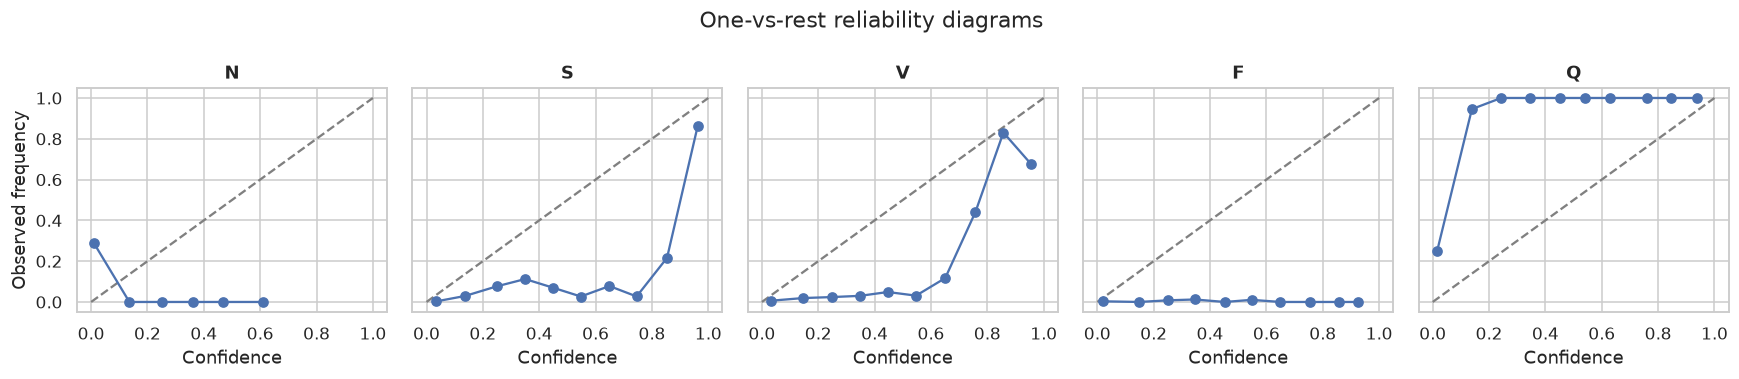

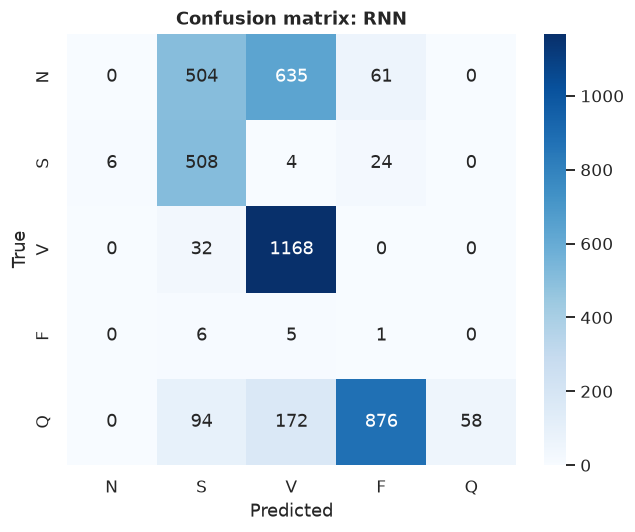

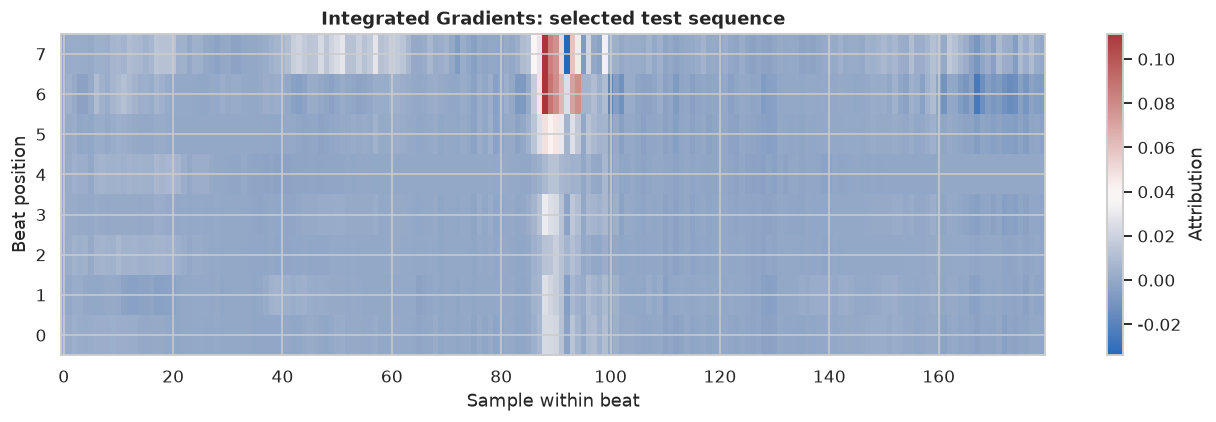

Best model: RNN | inference latency ms/example: 0.0211


pred_class,F,N,Q,S,V
true_class,,,,,
F,1,0,0,6,5
N,61,0,0,504,635
Q,876,0,58,94,172
S,24,6,0,508,4
V,0,0,0,32,1168


In [9]:
def reliability_plot(y,p,path):
    fig,axes=plt.subplots(1,len(CLASS_NAMES),figsize=(16,3.5),sharex=True,sharey=True); pred=p.argmax(1)
    for i,(ax,c) in enumerate(zip(axes,CLASS_NAMES)):
        conf=p[:,i]; truth=(y==i).astype(int); bins=np.linspace(0,1,11); xs=[]; ys=[]
        for lo,hi in zip(bins[:-1],bins[1:]):
            s=(conf>=lo)&(conf<=hi if hi==1 else conf<hi)
            if s.any(): xs.append(conf[s].mean()); ys.append(truth[s].mean())
        ax.plot([0,1],[0,1],'--',color='gray'); ax.plot(xs,ys,'o-'); ax.set_title(c); ax.set_xlabel('Confidence')
    axes[0].set_ylabel('Observed frequency'); fig.suptitle('One-vs-rest reliability diagrams'); fig.tight_layout(); fig.savefig(path,bbox_inches='tight'); plt.show()

def integrated_gradients(model,x,steps=20):
    model.eval(); xt=torch.tensor(x,dtype=torch.float32,device=CFG.device).unsqueeze(0); base=torch.zeros_like(xt); total=torch.zeros_like(xt)
    for a in torch.linspace(0,1,steps,device=CFG.device):
        xi=(base+a*(xt-base)).requires_grad_(True); model.zero_grad(); logits,_=model(xi); target=logits.argmax(1); logits[0,target].backward(); total += xi.grad.detach()
    return ((xt-base)*total/steps).detach().cpu().numpy()[0]

best_name=max(deep_metrics,key=lambda k:deep_metrics[k]['MacroF1']); best_model=deep_models[best_name]; test_loader=DataLoader(ECGDataset(X_test,y_test),batch_size=CFG.batch_size)
lat0=time.perf_counter(); yt,pt,att=infer_torch(best_model,test_loader); inference_latency_ms=float((time.perf_counter()-lat0)*1000/max(len(yt),1))
reliability_plot(yt,pt,OUTPUT/'plots'/'reliability_multiclass.png')
pred=pt.argmax(1); pred_df=meta_test.copy(); pred_df['true_class']=[CLASS_NAMES[i] for i in yt]; pred_df['pred_class']=[CLASS_NAMES[i] for i in pred]; pred_df['confidence']=pt.max(1); pred_df['correct']=yt==pred; pred_df.to_csv(OUTPUT/'predictions'/'test_predictions.csv',index=False)
cm=confusion_matrix(yt,pred,labels=np.arange(len(CLASS_NAMES))); plt.figure(figsize=(6,5)); sns.heatmap(cm,annot=True,fmt='d',xticklabels=CLASS_NAMES,yticklabels=CLASS_NAMES,cmap='Blues'); plt.xlabel('Predicted'); plt.ylabel('True'); plt.title(f'Confusion matrix: {best_name}'); plt.tight_layout(); plt.savefig(OUTPUT/'plots'/'confusion_matrix.png'); plt.show()
if att is not None and len(att):
    j=int(np.argmax(pt.max(1))); plt.figure(figsize=(8,3)); plt.bar(np.arange(CFG.sequence_length),att[j]); plt.xlabel('Beat position in sequence'); plt.ylabel('Attention weight'); plt.title('Temporal attention for a high-confidence test sequence'); plt.tight_layout(); plt.savefig(OUTPUT/'explanations'/'attention_example.png'); plt.show(); np.save(OUTPUT/'explanations'/'attention_weights.npy',att)
# Integrated Gradients on the highest-confidence test sequence.
j=int(np.argmax(pt.max(1))); ig=integrated_gradients(best_model,X_test[j]); np.save(OUTPUT/'explanations'/'integrated_gradients.npy',ig); plt.figure(figsize=(12,4)); plt.imshow(ig,aspect='auto',cmap='vlag',origin='lower'); plt.colorbar(label='Attribution'); plt.xlabel('Sample within beat'); plt.ylabel('Beat position'); plt.title('Integrated Gradients: selected test sequence'); plt.tight_layout(); plt.savefig(OUTPUT/'explanations'/'integrated_gradients.png'); plt.show()
print('Best model:',best_name,'| inference latency ms/example:',round(inference_latency_ms,4)); display(pred_df.groupby(['true_class','pred_class']).size().unstack(fill_value=0))

In [10]:
# Ablation: compare unidirectional LSTM with attention-capable bidirectional LSTM.
ablation=[]
for label,kind in [('LSTM_without_attention','LSTM'),('BiLSTM_with_attention','BiLSTM_Attention')]:
    m,_,_=train_model(kind); yy,pp,_=infer_torch(m,test_loader); ablation.append({'ablation':label,**multiclass_metrics(yy,pp)})
ablation_results=pd.DataFrame(ablation); ablation_results.to_csv(OUTPUT/'metrics'/'ablation_results.csv',index=False); display(ablation_results[['ablation','BalancedAccuracy','MacroF1','AUROC_OVR','AUPRC_macro','Brier_multiclass','ECE']])

,ablation,BalancedAccuracy,MacroF1,AUROC_OVR,AUPRC_macro,Brier_multiclass,ECE
0,LSTM_without_attention,0.397823,0.282796,0.727702,0.458094,0.978605,0.400538
1,BiLSTM_with_attention,0.400978,0.278500,0.760144,0.509492,0.996485,0.440121


In [11]:
# Save best checkpoint, preprocessing metadata, and UI-ready inference bundle.
best_model.cpu(); torch.save({'state_dict':best_model.state_dict(),'model_type':best_name,'input_shape':[CFG.sequence_length,CFG.beat_pre_samples+CFG.beat_post_samples],'class_names':CLASS_NAMES,'config':asdict(CFG)},OUTPUT/'models'/'best_model.pt'); best_model.to(CFG.device)
metrics_payload={k:{m:(None if pd.isna(v) else float(v) if isinstance(v,(np.floating,float)) else v) for m,v in val.items()} for k,val in results.to_dict('index').items()}
(OUTPUT/'metrics'/'metrics.json').write_text(json.dumps(metrics_payload,indent=2)); (OUTPUT/'metrics'/'inference_summary.json').write_text(json.dumps({'best_model':best_name,'inference_latency_ms_per_example':inference_latency_ms,'test_examples':len(y_test)},indent=2))
bundle={'model_type':best_name,'weights_path':'models/best_model.pt','class_names':CLASS_NAMES,'symbol_groups':AAMI,'sample_rate_hz':360,'beat_pre_samples':CFG.beat_pre_samples,'beat_post_samples':CFG.beat_post_samples,'sequence_length':CFG.sequence_length,'normalization':'per-beat robust median/MAD, clipped to +/-8','model_version':'vigil-arrhythmia-0.1','threshold':CFG.threshold,'inference_latency_ms_per_example':inference_latency_ms}
(OUTPUT/'configs'/'inference_bundle.json').write_text(json.dumps(bundle,indent=2))
for name,h in deep_histories.items(): h.to_csv(OUTPUT/'metrics'/f'{name}_training_history.csv',index=False)

In [12]:
# Clean inference function for later FastAPI/UI extraction.
def predict_ecg(signal, model=None, bundle_path=None):
    arr=np.asarray(signal,dtype=np.float32).reshape(-1)
    if len(arr) < CFG.beat_pre_samples+CFG.beat_post_samples: raise ValueError('signal must contain at least one complete beat window')
    if model is None: model=best_model
    model.eval(); center=len(arr)//2; beat=arr[center-CFG.beat_pre_samples:center+CFG.beat_post_samples].copy(); med=np.median(beat); scale=np.median(np.abs(beat-med))*1.4826; scale=scale if np.isfinite(scale) and scale>1e-6 else np.std(beat)+1e-6; beat=np.clip((beat-med)/scale,-8,8).astype(np.float32)
    seq=np.zeros((CFG.sequence_length,len(beat)),dtype=np.float32); seq[-1]=beat
    with torch.no_grad(): logits,att=model(torch.tensor(seq).unsqueeze(0).to(CFG.device)); probs=torch.softmax(logits,1).cpu().numpy()[0]
    top=int(np.argmax(probs)); attention=[] if att is None else [{'beat_position':int(i),'weight':float(w)} for i,w in enumerate(att.cpu().numpy()[0])]
    return {'class_name':CLASS_NAMES[top],'class_index':top,'probabilities':{c:float(probs[i]) for i,c in enumerate(CLASS_NAMES)},'model_version':'vigil-arrhythmia-0.1','attention':attention}

In [13]:
# Research summary and final measured result block.
summary=f"""# VIGIL arrhythmia research summary

## Problem
Beat-level multiclass ECG arrhythmia classification over AAMI-style N/S/V/F/Q research groups.

## Dataset
Kaggle mirror `{CFG.kaggle_dataset}` of the MIT-BIH Arrhythmia Database. Records are read as WFDB signals and expert annotations.

## Leakage control
Subject/record groups are split before beat construction and no beat from a held-out group enters training. Temporal sequences use only the current and preceding beats within each record.

## Preprocessing
Channel 0 at 360 Hz; 90 samples before and after each annotation; per-beat robust median/MAD normalization; clipping at +/-8; sequence length {CFG.sequence_length}.

## Models
Logistic Regression, Random Forest, RNN, LSTM, GRU, BiLSTM, and BiLSTM with temporal attention. Class-weighted cross entropy is used for the neural models.

## Measured results
{{results[['Accuracy','BalancedAccuracy','MacroF1','AUROC_OVR','AUPRC_macro','Brier_multiclass','ECE']].round(4).to_string()}}

## Explainability and limitations
Attention and Integrated Gradients are descriptive analyses; neither establishes causality. Dataset shift, record-level morphology, annotation uncertainty, class imbalance, limited subject count, and the Kaggle mirror provenance limit generalization. This is not a clinical diagnostic product.

## Reproducibility and deployment
The checkpoint, label mapping, preprocessing configuration, inference bundle, predictions, plots, metrics, and training histories are exported under `artifacts_arrhythmia/`.
"""
(OUTPUT/'reports'/'research_summary.md').write_text(summary)
print('================ VIGIL ARRHYTHMIA RESULTS ================')
print('Best Model:',best_name); print('Macro-F1:',round(deep_metrics[best_name]['MacroF1'],4)); print('AUROC OVR:',round(deep_metrics[best_name]['AUROC_OVR'],4)); print('AUPRC macro:',round(deep_metrics[best_name]['AUPRC_macro'],4)); print('Balanced Accuracy:',round(deep_metrics[best_name]['BalancedAccuracy'],4)); print('ECE:',round(deep_metrics[best_name]['ECE'],4)); print('Inference Latency (ms/example):',round(inference_latency_ms,4)); print('Weights:',OUTPUT/'models'/'best_model.pt'); print('===========================================================')

================ VIGIL ARRHYTHMIA RESULTS ================
Best Model: RNN
Macro-F1: 0.2861
AUROC OVR: 0.772
AUPRC macro: 0.5614
Balanced Accuracy: 0.4085
ECE: 0.4014
Inference Latency (ms/example): 0.0211
Weights: artifacts_arrhythmia/models/best_model.pt


## References

[1]: https://www.kaggle.com/datasets/abdallahwagih/mit-bih-arrhythmia-database "MIT-BIH Arrhythmia Database — Abdallah Wagih Ibrahim"

[2]: https://physionet.org/content/mitdb/1.0.0/ "MIT-BIH Arrhythmia Database on PhysioNet"

[3]: https://arxiv.org/abs/1902.10186 "Jain and Wallace. Attention is not Explanation"